# Assignment 1 – Introduction to Machine Learning

## Introduction

This assignment focuses on applying fundamental machine learning concepts to real-world datasets through **two main tasks: classification and regression**. The goal is to understand how different types of machine learning problems are solved, how models are trained and evaluated, and how data preparation affects model performance.

Machine learning models are only as good as the data and the evaluation process used to train and test them. Therefore, this assignment emphasizes three essential stages of a machine learning workflow:

1. Data preprocessing and balancing
2. Proper dataset splitting (training, validation, testing)
3. Model evaluation using appropriate performance metrics

In the first part of the assignment, a **classification model** is built to distinguish between gamma and hadron events using the MAGIC telescope dataset. In the second part, **regression models** are applied to predict house prices using the California housing dataset. This allows us to compare how machine learning techniques differ when predicting discrete classes versus continuous numerical values.

---

# Part 1 – Classification Problem

## Problem Description

The task is to classify events recorded by the MAGIC gamma telescope dataset into one of two categories:

* **Gamma (g)** – signal events
* **Hadron (h)** – background noise events

This is a **binary classification problem**, where the model must predict which class an event belongs to based on numerical features extracted from telescope images.

---

## Dataset Characteristics

The dataset contains several numerical features describing the shape and intensity of the particle image, such as:

* Length and width of the particle shower
* Concentration of light in pixels
* Distance from the center of the telescope camera

The dataset is **imbalanced**, meaning one class contains more samples than the other. This can cause machine learning models to become biased toward the majority class, resulting in misleading accuracy.

---

## Machine Learning Workflow Used in This Notebook

The following steps are performed to build a reliable classification system:

### 1. Data Loading

The dataset is first loaded using pandas and inspected to ensure it is correctly formatted and contains no structural issues.

### 2. Data Balancing

Since the dataset is imbalanced, random downsampling is applied to the majority class to ensure both classes contain the same number of samples. This helps the model learn patterns from both classes equally.

### 3. Feature and Label Separation

The dataset is divided into:

* **Features (X):** Numerical attributes used to make predictions
* **Labels (y):** The target class (gamma or hadron)

### 4. Dataset Splitting

The data is divided into three parts:

* **Training set (70%)** – used to train the model
* **Validation set (15%)** – used to tune hyperparameters such as the value of K
* **Testing set (15%)** – used only once to evaluate final model performance

This ensures that the model does not memorize the data and provides an unbiased estimate of performance.

---

# K-Nearest Neighbors (KNN) Algorithm

## Concept of KNN

K-Nearest Neighbors is a **supervised learning algorithm** used for classification tasks. It works by comparing a new data point to existing labeled data points and assigning the class that appears most frequently among its nearest neighbors.

### How it works

1. Choose a value for **K**
2. Measure distance between data points (usually Euclidean distance)
3. Select the K closest samples
4. Assign the class that appears most often among them

KNN is simple but powerful, especially for datasets where class boundaries are not linear.

---

# Choosing the Best Value of K

Different values of K can significantly affect model performance:

* Small K → sensitive to noise (overfitting)
* Large K → overly smooth decision boundaries (underfitting)

In this notebook, multiple values of K are tested and evaluated using the validation set to determine the optimal configuration.

---

# Model Evaluation Metrics

To properly evaluate the classification model, several metrics are used instead of relying only on accuracy.

## 1. Accuracy

Accuracy measures the proportion of correctly classified samples out of all predictions.

## 2. Precision

Precision measures how many of the samples predicted as gamma were actually gamma. This is important when false positives are costly.

## 3. Recall

Recall measures how many actual gamma events were correctly identified. This is important when missing a gamma event is undesirable.

## 4. F1 Score

The F1 score is the harmonic mean of precision and recall and provides a balanced evaluation of both metrics.

## 5. Confusion Matrix

The confusion matrix provides a detailed breakdown of prediction results:

* True Positives
* True Negatives
* False Positives
* False Negatives

This helps in understanding the types of errors made by the model.

---

# Experimental Procedure

The following experiments are conducted in this notebook:

1. Train multiple KNN models using different values of K
2. Evaluate each model on the validation set
3. Select the best performing model
4. Evaluate the final model on the test set

---

# Results and Discussion

The performance of each KNN model is analyzed based on the evaluation metrics. The selected model represents the best trade-off between underfitting and overfitting.

Observations include:

* How performance changes as K increases
* Whether the model shows signs of overfitting
* Which metric is most sensitive to class imbalance

---

---

# Part 2 – Regression Problem

## Problem Description

The second part of the assignment focuses on predicting **continuous numerical values** rather than discrete classes. In this case, the goal is to predict **median house prices** using the California Housing dataset.

This is a **regression task**, where the model learns a relationship between input features (such as income, location, and population) and a continuous target value (house price).

---

## Dataset Overview

The California Housing dataset contains several numerical features describing each district, including:

* Median income
* Median house age
* Total number of rooms and bedrooms
* Population and number of households
* Geographic information such as latitude, longitude, and distance to major cities

These features are used to estimate the **median house value** for each district.

---

## Regression Models Used

Three different regression models are applied and compared:

### 1. Linear Regression

Linear regression assumes a linear relationship between the features and the target variable. It is the simplest regression model and serves as a baseline for comparison.

### 2. Ridge Regression

Ridge regression is a regularized version of linear regression that adds a penalty to large coefficient values. This helps reduce overfitting and improves generalization when features are highly correlated.

### 3. Lasso Regression

Lasso regression also applies regularization but has the additional ability to shrink some coefficients to zero, effectively performing feature selection.

---

## Workflow for the Regression Task

The same structured machine learning pipeline used in classification is applied here:

1. Load and inspect the dataset
2. Split the dataset into training, validation, and testing sets
3. Train multiple regression models
4. Evaluate model performance using regression metrics
5. Compare the models and discuss the results

---

## Regression Evaluation Metrics

Unlike classification, regression models are evaluated using error-based metrics rather than accuracy.

### 1. Mean Squared Error (MSE)

Mean Squared Error measures the average of the squared differences between predicted and actual values. It heavily penalizes large errors.

### 2. Mean Absolute Error (MAE)

Mean Absolute Error measures the average absolute difference between predicted and actual values. It is easier to interpret because it is in the same unit as the target variable.

These metrics allow us to quantify how close the model predictions are to the true house prices.

---

## Experimental Procedure for Regression

The following experiments are conducted:

1. Train Linear Regression, Ridge Regression, and Lasso Regression models
2. Evaluate each model using MSE and MAE
3. Compare their performance to determine which model provides the most accurate predictions

---

# Overall Conclusion

This assignment demonstrates two fundamental types of supervised learning problems:

* **Classification**, where the objective is to assign data points to discrete categories
* **Regression**, where the objective is to predict continuous numerical values

Through these experiments, we gain practical experience in data preprocessing, model training, hyperparameter tuning, and performance evaluation. The assignment highlights how different machine learning algorithms behave under different problem types and emphasizes the importance of selecting appropriate models and evaluation metrics for each task.


In [33]:
# Import libraries
import numpy as np
import pandas as pd

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [34]:
# Load dataset
data = pd.read_csv("magic04.data")

In [35]:
# Show first rows
data.head()

,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.011,-8.2027,40.092,81.8828,g
0,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.261,g
1,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.788,g
2,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.737,g
3,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.462,g
4,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.098,g


In [36]:
data.columns = [
    'fLength','fWidth','fSize','fConc','fConc1',
    'fAsym','fM3Long','fM3Trans','fAlpha','fDist','class'
]

In [37]:
data.sample(5)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
13597,46.7377,8.3832,2.7473,0.4547,0.2578,-7.3423,19.9418,-9.9093,78.1362,245.9702,h
11462,50.7410,36.7379,3.8913,0.1335,0.0678,4.3911,39.5033,14.2597,18.8500,135.6050,g
9033,31.6204,14.3757,2.7462,0.3605,0.1892,-11.9099,22.5139,6.0822,11.5864,199.3630,g
863,92.9014,26.8157,3.5101,0.2558,0.1608,-3.3896,33.3066,10.9488,0.0323,327.0640,g
6318,25.2333,7.5107,2.3222,0.6810,0.3881,-13.0080,11.1798,5.0984,17.1998,137.8240,g


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19019 entries, 0 to 19018
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19019 non-null  float64
 1   fWidth    19019 non-null  float64
 2   fSize     19019 non-null  float64
 3   fConc     19019 non-null  float64
 4   fConc1    19019 non-null  float64
 5   fAsym     19019 non-null  float64
 6   fM3Long   19019 non-null  float64
 7   fM3Trans  19019 non-null  float64
 8   fAlpha    19019 non-null  float64
 9   fDist     19019 non-null  float64
 10  class     19019 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


In [39]:
data.describe()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
count,19019.000000,19019.000000,19019.000000,19019.000000,19019.000000,19019.000000,19019.000000,19019.000000,19019.000000,19019.000000
mean,53.251440,22.181291,2.825026,0.380326,0.214658,-4.333429,10.544942,0.250170,27.645052,193.823912
std,42.365598,18.346484,0.472609,0.182818,0.110514,59.207163,51.001391,20.827896,26.104151,74.729344
min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600
25%,24.336000,11.863700,2.477100,0.235800,0.128450,-20.588300,-12.845050,-10.849750,5.546950,142.499000
50%,37.149000,17.140600,2.739600,0.354100,0.196500,4.011900,15.309400,0.689800,17.677000,191.856900
75%,70.126850,24.739950,3.101600,0.503700,0.285250,24.060350,35.844100,10.947050,45.884100,240.564550
max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000


In [40]:
print(data.isnull().sum())

fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0
dtype: int64


In [41]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
19014    False
19015    False
19016    False
19017    False
19018    False
Length: 19019, dtype: bool

In [42]:
# Separate classes
gamma = data[data['class'] == 'g']
hadron = data[data['class'] == 'h']

# Downsample gamma to match hadron size
gamma_balanced = gamma.sample(len(hadron), random_state=42)

# Combine again
data_balanced = pd.concat([gamma_balanced, hadron])

In [43]:
data_balanced = data_balanced.sample(frac=1, random_state=42)

In [44]:
X = data_balanced.drop('class', axis=1)
y = data_balanced['class']

In [45]:
# First split: train and temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

In [46]:
k_values = [1, 3, 5, 7, 9]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    print(f"K={k} -> Accuracy: {acc}")

K=1 -> Accuracy: 0.7497507477567298
K=3 -> Accuracy: 0.7637088733798604
K=5 -> Accuracy: 0.7681954137587238
K=7 -> Accuracy: 0.7716849451645065
K=9 -> Accuracy: 0.7806580259222333


## Visualization of KNN Performance

To better understand how the value of K affects model performance, a graph is plotted showing the relationship between K and validation accuracy. This visualization helps identify the optimal value of K and illustrates the trend of model improvement as the neighborhood size increases.

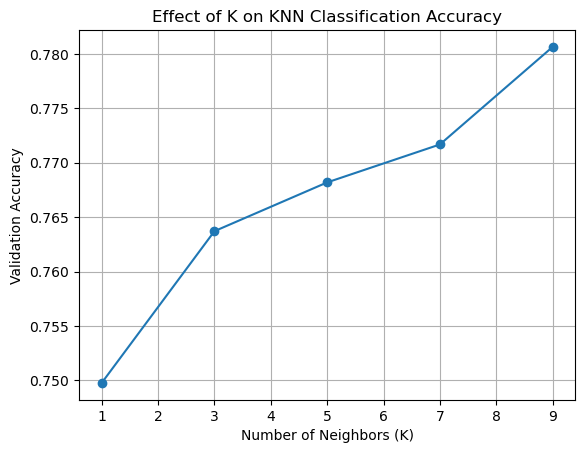

In [47]:
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7, 9]
accuracies = [0.7497507477567298,
              0.7637088733798604,
              0.7681954137587238,
              0.7716849451645065,
              0.7806580259222333]

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Validation Accuracy")
plt.title("Effect of K on KNN Classification Accuracy")
plt.grid(True)

plt.show()

In [48]:
best_k = 9
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [49]:
y_pred = model.predict(X_test)

In [50]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label='g')
rec = recall_score(y_test, y_pred, pos_label='g')
f1 = f1_score(y_test, y_pred, pos_label='g')
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7563527653213752
Precision: 0.7060322854715378
Recall: 0.8531827515400411
F1 Score: 0.7726638772663877
Confusion Matrix:
 [[831 143]
 [346 687]]


### Model Evaluation

Different values of K were tested to evaluate their impact on classification accuracy.  
It was observed that the accuracy improved as the value of K increased.

Small values of K such as K=1 resulted in lower accuracy due to sensitivity to noise and overfitting.  
Larger values provided more stable predictions by considering more neighbors during classification.

The best performance was achieved at **K = 9**, which produced the highest validation accuracy.

This trend suggests that the dataset contains noise, and using a larger neighborhood helps smooth the decision boundary.

In [51]:
import pandas as pd
data = pd.read_csv("California_Houses.csv")
data

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,78100.0,1.5603,25,1665,374,845,330,39.48,-121.09,162031.481121,654530.186299,830631.543047,248510.058162,222619.890417
20636,77100.0,2.5568,18,697,150,356,114,39.49,-121.21,160445.433537,659747.068444,836245.915229,246849.888948,218314.424634
20637,92300.0,1.7000,17,2254,485,1007,433,39.43,-121.22,153754.341182,654042.214020,830699.573163,240172.220489,212097.936232
20638,84700.0,1.8672,18,1860,409,741,349,39.43,-121.32,152005.022239,657698.007703,834672.461887,238193.865909,207923.199166


In [52]:
data.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568


In [53]:
data.sample()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
10497,120400.0,4.0388,17,2112,480,1893,433,33.51,-117.67,11434.461232,80289.978414,100232.768992,572024.26468,640052.845621


In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Median_House_Value        20640 non-null  float64
 1   Median_Income             20640 non-null  float64
 2   Median_Age                20640 non-null  int64  
 3   Tot_Rooms                 20640 non-null  int64  
 4   Tot_Bedrooms              20640 non-null  int64  
 5   Population                20640 non-null  int64  
 6   Households                20640 non-null  int64  
 7   Latitude                  20640 non-null  float64
 8   Longitude                 20640 non-null  float64
 9   Distance_to_coast         20640 non-null  float64
 10  Distance_to_LA            20640 non-null  float64
 11  Distance_to_SanDiego      20640 non-null  float64
 12  Distance_to_SanJose       20640 non-null  float64
 13  Distance_to_SanFrancisco  20640 non-null  float64
dtypes: flo

In [55]:
data.describe()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,2.064000e+04,2.064000e+04,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,2635.763081,537.898014,1425.476744,499.539680,35.631861,-119.569704,40509.264883,2.694220e+05,3.981649e+05,349187.551219,386688.422291
std,115395.615874,1.899822,12.585558,2181.615252,421.247906,1132.462122,382.329753,2.135952,2.003532,49140.039160,2.477324e+05,2.894006e+05,217149.875026,250122.192316
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000,120.676447,4.205891e+02,4.849180e+02,569.448118,456.141313
25%,119600.000000,2.563400,18.000000,1447.750000,295.000000,787.000000,280.000000,33.930000,-121.800000,9079.756762,3.211125e+04,1.594264e+05,113119.928682,117395.477505
50%,179700.000000,3.534800,29.000000,2127.000000,435.000000,1166.000000,409.000000,34.260000,-118.490000,20522.019101,1.736675e+05,2.147398e+05,459758.877000,526546.661701
75%,264725.000000,4.743250,37.000000,3148.000000,647.000000,1725.000000,605.000000,37.710000,-118.010000,49830.414479,5.271562e+05,7.057954e+05,516946.490963,584552.007907
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000,333804.686371,1.018260e+06,1.196919e+06,836762.678210,903627.663298


In [56]:
print(data.isnull().sum())

Median_House_Value          0
Median_Income               0
Median_Age                  0
Tot_Rooms                   0
Tot_Bedrooms                0
Population                  0
Households                  0
Latitude                    0
Longitude                   0
Distance_to_coast           0
Distance_to_LA              0
Distance_to_SanDiego        0
Distance_to_SanJose         0
Distance_to_SanFrancisco    0
dtype: int64


In [57]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
20635    False
20636    False
20637    False
20638    False
20639    False
Length: 20640, dtype: bool

In [58]:
X = data.drop("Median_House_Value", axis=1)
y = data["Median_House_Value"]
print(X)
print(X.columns)
print('-----------------')
print('-----------------')
print('-----------------')
print('-----------------')

print(y)

       Median_Income  Median_Age  Tot_Rooms  Tot_Bedrooms  Population  \
0             8.3252          41        880           129         322   
1             8.3014          21       7099          1106        2401   
2             7.2574          52       1467           190         496   
3             5.6431          52       1274           235         558   
4             3.8462          52       1627           280         565   
...              ...         ...        ...           ...         ...   
20635         1.5603          25       1665           374         845   
20636         2.5568          18        697           150         356   
20637         1.7000          17       2254           485        1007   
20638         1.8672          18       1860           409         741   
20639         2.3886          16       2785           616        1387   

       Households  Latitude  Longitude  Distance_to_coast  Distance_to_LA  \
0             126     37.88    -122.23        

In [59]:
from sklearn.model_selection import train_test_split
# The dataset was randomly split into 70% training, 15% validation, and 15% testing.
# The training set is used to train the models, validation for tuning, and testing for final evaluation.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Feature scaling was applied using StandardScaler to normalize the data.
# This helps improve model performance, especially for Ridge and Lasso regression.

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [61]:
from sklearn.linear_model import LinearRegression
# Linear Regression is used as a baseline model.
# It assumes a linear relationship between features and the target variable.
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [62]:
from sklearn.linear_model import Ridge

# Ridge Regression applies L2 regularization to reduce overfitting.
# It shrinks coefficients but does not eliminate any feature.

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [63]:
from sklearn.linear_model import Lasso

# Lasso Regression applies L1 regularization.
# It can reduce some coefficients to zero, effectively performing feature selection. 

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

d:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.243e+13, tolerance: 1.936e+10
  model = cd_fast.enet_coordinate_descent(


In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# We used Mean Squared Error (MSE) and Mean Absolute Error (MAE)
# to evaluate model performance.
# Lower values indicate better model performance.

def evaluate(name, y_true, y_pred):
    print(name)
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("-----------------------------------------------")

evaluate("Linear", y_test, y_pred_lr)
evaluate("Ridge", y_test, y_pred_ridge)
evaluate("Lasso", y_test, y_pred_lasso)

# Ridge Regression achieved better performance due to regularization reducing overfitting.
# Lasso Regression simplified the model by removing less important features.
# Linear Regression performed well but is more sensitive to overfitting.


# Based on the results, Ridge Regression gave the lowest error,
# making it the best model for this dataset.

Linear
MSE: 4400953150.613742
MAE: 48782.031080856716
-----------------------------------------------
Ridge
MSE: 4400540039.597483
MAE: 48784.33026729787
-----------------------------------------------
Lasso
MSE: 4400721834.3478565
MAE: 48781.71310189875
-----------------------------------------------
